In [1]:
# ====================================================
# Step_03_Transformer_model.ipynb
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
# ====================================================
# 1. Load preprocessed arrays from Step_02
# ====================================================

# ---------- 1-hour ahead data ----------
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
t_train = np.load("t_train.npy")

X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")
t_test  = np.load("t_test.npy")

X_eval  = np.load("X_eval.npy")
y_eval  = np.load("y_eval.npy")
t_eval  = np.load("t_eval.npy")

# ---------- 24-hour ahead data ----------
X_train_24 = np.load("X_train_24.npy")
y_train_24 = np.load("y_train_24.npy")
t_train_24 = np.load("t_train_24.npy")

X_test_24  = np.load("X_test_24.npy")
y_test_24  = np.load("y_test_24.npy")
t_test_24  = np.load("t_test_24.npy")

X_eval_24  = np.load("X_eval_24.npy")
y_eval_24  = np.load("y_eval_24.npy")
t_eval_24  = np.load("t_eval_24.npy")

print("X_train (1h):", X_train.shape, "y_train:", y_train.shape)
print("X_train_24  :", X_train_24.shape, "y_train_24:", y_train_24.shape)

seq_len = X_train.shape[1]
n_features = X_train.shape[2]
print("Sequence length:", seq_len, "| n_features:", n_features)


X_train (1h): (41450, 24, 35) y_train: (41450,)
X_train_24  : (41427, 24, 35) y_train_24: (41427, 24)
Sequence length: 24 | n_features: 35


In [3]:
# ====================================================
# 2. Transformer building blocks
# ====================================================

class PositionalEncoding(layers.Layer):
    """
    Learned positional encoding for sequences.
    Adds a trainable vector for each position 0..seq_len-1.
    """
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        self.pos_embedding = layers.Embedding(input_dim=sequence_length,
                                              output_dim=d_model)

    def call(self, inputs):
        # inputs: (batch, seq_len, d_model)
        seq_len = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        position_embeddings = self.pos_embedding(positions)  # (seq_len, d_model)
        return inputs + position_embeddings

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "d_model": self.d_model,
        })
        return config


class TransformerEncoder(layers.Layer):
    """
    A single Transformer encoder block: MH attention + FFN + residuals.
    """
    def __init__(self,
                 d_model,
                 num_heads,
                 ff_dim,
                 dropout=0.1,
                 **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=d_model)
        self.dropout_1 = layers.Dropout(dropout)
        self.norm_1 = layers.LayerNormalization(epsilon=1e-6)

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.dropout_2 = layers.Dropout(dropout)
        self.norm_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=False):
        # Self-attention
        attn_output = self.mha(inputs, inputs)
        attn_output = self.dropout_1(attn_output, training=training)
        out1 = self.norm_1(inputs + attn_output)

        # Feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout_2(ffn_output, training=training)
        out2 = self.norm_2(out1 + ffn_output)
        return out2

    def get_config(self):
        config = super().get_config()
        return config


In [4]:
# ====================================================
# 3. Model builders (1h and 24h)
# ====================================================

def build_transformer_model_1h(seq_len,
                               n_features,
                               d_model=64,
                               num_heads=4,
                               ff_dim=128,
                               num_layers=2,
                               dropout=0.1):
    """
    Transformer model that predicts 1-hour ahead (single value).
    """
    inputs = keras.Input(shape=(seq_len, n_features))

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(sequence_length=seq_len, d_model=d_model)(x)

    for _ in range(num_layers):
        x = TransformerEncoder(d_model=d_model,
                               num_heads=num_heads,
                               ff_dim=ff_dim,
                               dropout=dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="linear")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="transformer_energy_1h")
    return model


def build_transformer_model_24h(seq_len,
                                n_features,
                                d_model=64,
                                num_heads=4,
                                ff_dim=128,
                                num_layers=2,
                                dropout=0.1):
    """
    Transformer model that predicts next 24 hours (vector of length 24).
    """
    inputs = keras.Input(shape=(seq_len, n_features))

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(sequence_length=seq_len, d_model=d_model)(x)

    for _ in range(num_layers):
        x = TransformerEncoder(d_model=d_model,
                               num_heads=num_heads,
                               ff_dim=ff_dim,
                               dropout=dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(24, activation="linear")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="transformer_energy_24h")
    return model


In [5]:
# ====================================================
# 4. Train 1-hour ahead Transformer
# ====================================================

model_1h = build_transformer_model_1h(
    seq_len=seq_len,
    n_features=n_features,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_layers=2,
    dropout=0.1,
)

model_1h.summary()

model_1h.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

checkpoint_cb_1h = keras.callbacks.ModelCheckpoint(
    "transformer_energy_1h.keras",    # <- 1-hour model file
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

early_stopping_cb_1h = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_1h = model_1h.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[checkpoint_cb_1h, early_stopping_cb_1h],
    verbose=1
)


Model: "transformer_energy_1h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 35)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 64)         │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 24, 64)         │         1,536 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 24, 64)         │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 24, 64)         │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,465 (681.50 KB)

 Trainable params: 174,465 (681.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - loss: 0.1235 - mae: 0.2124 - val_loss: 0.1285 - val_mae: 0.1895
Epoch 2/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - loss: 0.0568 - mae: 0.1489 - val_loss: 0.0909 - val_mae: 0.1501
Epoch 3/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/step - loss: 0.0499 - mae: 0.1346 - val_loss: 0.1179 - val_mae: 0.1546
Epoch 4/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - loss: 0.0451 - mae: 0.1261 - val_loss: 0.1083 - val_mae: 0.1486
Epoch 5/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - loss: 0.0427 - mae: 0.1193 - val_loss: 0.0880 - val_mae: 0.1410
Epoch 6/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - loss: 0.0394 - mae: 0.1113 - val_loss: 0.1139 - val_mae: 0.2101
Epoch 7/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - loss: 0.0387 - mae: 0.1091 - val_loss: 0.0721 - val_mae: 0.1079
Epoch 8/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - loss: 0.0370 - mae: 0.1031 - val_loss: 0.1079 - val_mae: 0.1644
Epoch 9/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 

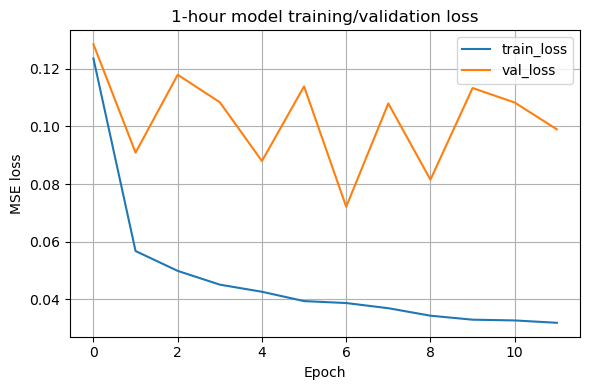

In [6]:
# ====================================================
# 5. 1-hour model — training curves
# ====================================================

plt.figure(figsize=(6, 4))
plt.plot(history_1h.history["loss"], label="train_loss")
plt.plot(history_1h.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("1-hour model training/validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



1-hour model: evaluation on TEST set (2020-10-01 to 2021-09-30)
  Test MSE: 0.0721, MAE: 0.1079, RMSE: 0.2686

1-hour model: evaluation on full EVAL set (2021-10-01 to 2022-05-31)
  Eval MSE: 0.0485, MAE: 0.0946, RMSE: 0.2203

1-hour model (overall evaluation period):
  MSE  = 0.0485
  RMSE = 0.2203
  MAE  = 0.0946


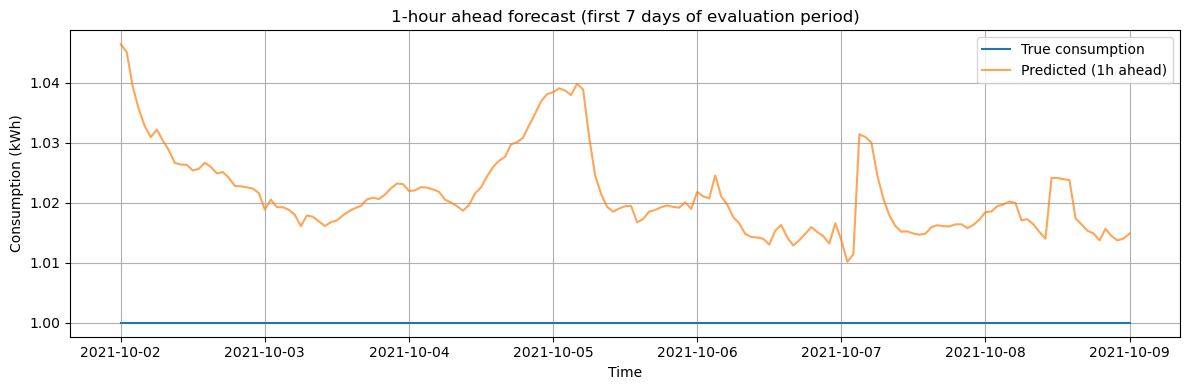

In [7]:
# ====================================================
# 6. 1-hour model — evaluation & plots
# ====================================================

# --- basic test & eval metrics ---
print("\n1-hour model: evaluation on TEST set (2020-10-01 to 2021-09-30)")
test_loss, test_mae = model_1h.evaluate(X_test, y_test, verbose=0)
print(f"  Test MSE: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_loss**0.5:.4f}")

print("\n1-hour model: evaluation on full EVAL set (2021-10-01 to 2022-05-31)")
eval_loss, eval_mae = model_1h.evaluate(X_eval, y_eval, verbose=0)
print(f"  Eval MSE: {eval_loss:.4f}, MAE: {eval_mae:.4f}, RMSE: {eval_loss**0.5:.4f}")

# --- predictions for detailed analysis ---
y_pred_eval_1h = model_1h.predict(X_eval, verbose=0).ravel()

mse_1h = mean_squared_error(y_eval, y_pred_eval_1h)
mae_1h = mean_absolute_error(y_eval, y_pred_eval_1h)
rmse_1h = mse_1h ** 0.5

print("\n1-hour model (overall evaluation period):")
print(f"  MSE  = {mse_1h:.4f}")
print(f"  RMSE = {rmse_1h:.4f}")
print(f"  MAE  = {mae_1h:.4f}")

# Build DataFrame with timestamp for plotting
eval_df_1h = pd.DataFrame({
    "time": pd.to_datetime(t_eval),
    "y_true": y_eval,
    "y_pred": y_pred_eval_1h,
}).set_index("time")

# --- plot first 7 days of evaluation period ---
start_date = eval_df_1h.index.min()
end_date = start_date + pd.Timedelta(days=7)

plot_df = eval_df_1h.loc[start_date:end_date]

plt.figure(figsize=(12, 4))
plt.plot(plot_df.index, plot_df["y_true"], label="True consumption")
plt.plot(plot_df.index, plot_df["y_pred"], label="Predicted (1h ahead)", alpha=0.7)
plt.title("1-hour ahead forecast (first 7 days of evaluation period)")
plt.xlabel("Time")
plt.ylabel("Consumption (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# ====================================================
# 7. 1-hour model — metrics for 3 evaluation windows
#    (as required in assignment)
# ====================================================

eval_df_1h = eval_df_1h.sort_index()

windows = [
    ("2021-10-01", "2021-12-31"),
    ("2022-01-01", "2022-02-28"),
    ("2022-03-01", "2022-05-31"),
]

for start, end in windows:
    mask = (eval_df_1h.index >= start) & (eval_df_1h.index <= end)
    sub = eval_df_1h.loc[mask]
    mse = mean_squared_error(sub["y_true"], sub["y_pred"])
    mae = mean_absolute_error(sub["y_true"], sub["y_pred"])
    rmse = mse ** 0.5
    print(f"{start} to {end} -> MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")


2021-10-01 to 2021-12-31 -> MSE: 0.0495, RMSE: 0.2224, MAE: 0.0974
2022-01-01 to 2022-02-28 -> MSE: 0.0837, RMSE: 0.2892, MAE: 0.1286
2022-03-01 to 2022-05-31 -> MSE: 0.0248, RMSE: 0.1576, MAE: 0.0710


In [9]:
# ====================================================
# 8. Train 24-hour ahead Transformer
# ====================================================

model_24h = build_transformer_model_24h(
    seq_len=seq_len,
    n_features=n_features,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_layers=2,
    dropout=0.1,
)

model_24h.summary()

model_24h.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

checkpoint_cb_24 = keras.callbacks.ModelCheckpoint(
    "transformer_energy_24h.keras",    # <- 24-hour model file
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

early_stopping_cb_24 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_24h = model_24h.fit(
    X_train_24, y_train_24,
    validation_data=(X_test_24, y_test_24),
    epochs=50,
    batch_size=64,
    callbacks=[checkpoint_cb_24, early_stopping_cb_24],
    verbose=1
)


Model: "transformer_energy_24h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 24, 35)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24, 64)         │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 24, 64)         │         1,536 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 24, 64)         │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 24, 64)         │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,960 (687.34 KB)

 Trainable params: 175,960 (687.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 48s 65ms/step - loss: 0.3017 - mae: 0.3345 - val_loss: 0.3350 - val_mae: 0.3270
Epoch 2/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 0.1509 - mae: 0.2338 - val_loss: 0.3329 - val_mae: 0.3298
Epoch 3/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - loss: 0.1282 - mae: 0.2122 - val_loss: 0.3477 - val_mae: 0.3198
Epoch 4/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 0.1126 - mae: 0.1983 - val_loss: 0.4059 - val_mae: 0.3711
Epoch 5/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 0.0968 - mae: 0.1824 - val_loss: 0.3884 - val_mae: 0.3543
Epoch 6/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 0.0887 - mae: 0.1713 - val_loss: 0.4522 - val_mae: 0.3668
Epoch 7/50
648/648 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - loss: 0.0816 - mae: 0.1610 - val_loss: 0.4390 - val_mae: 0.3763


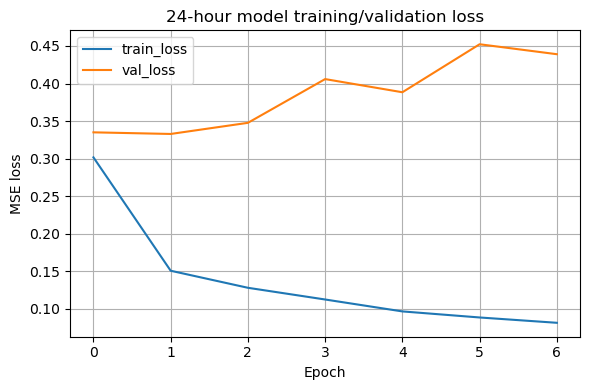

In [10]:
# ====================================================
# 9. 24-hour model — training curves
# ====================================================

plt.figure(figsize=(6, 4))
plt.plot(history_24h.history["loss"], label="train_loss")
plt.plot(history_24h.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("24-hour model training/validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


24-hour ahead forecast (evaluation period, all horizons):
  MSE  = 0.2554
  RMSE = 0.5054
  MAE  = 0.3166


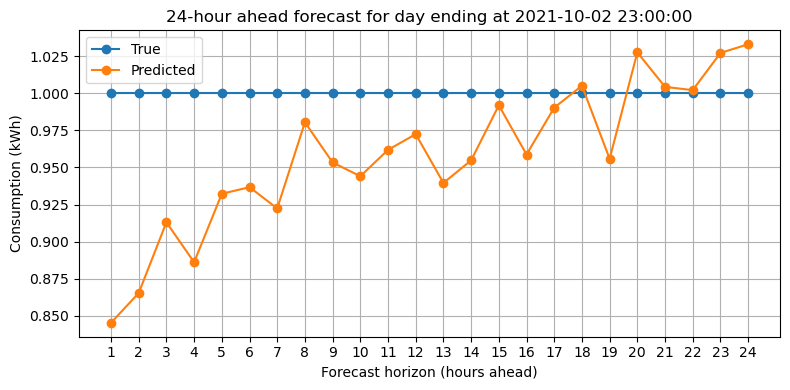

In [11]:
# ====================================================
# 10. 24-hour model — evaluation & plots
# ====================================================

# Predict on evaluation set
y_pred_eval_24h = model_24h.predict(X_eval_24, verbose=0)  # shape (N, 24)

# Flatten for global metrics across all horizons
y_true_flat = y_eval_24.reshape(-1)
y_pred_flat = y_pred_eval_24h.reshape(-1)

mse_24 = mean_squared_error(y_true_flat, y_pred_flat)
mae_24 = mean_absolute_error(y_true_flat, y_pred_flat)
rmse_24 = mse_24 ** 0.5

print("24-hour ahead forecast (evaluation period, all horizons):")
print(f"  MSE  = {mse_24:.4f}")
print(f"  RMSE = {rmse_24:.4f}")
print(f"  MAE  = {mae_24:.4f}")

# ----- Example plot: 24-hour forecast for one day -----
idx = 0  # you can change this index to look at different days

example_true = y_eval_24[idx]        # shape (24,)
example_pred = y_pred_eval_24h[idx]  # shape (24,)
example_time = pd.to_datetime(t_eval_24[idx])

hours_ahead = np.arange(1, 25)

plt.figure(figsize=(8, 4))
plt.plot(hours_ahead, example_true, marker="o", label="True")
plt.plot(hours_ahead, example_pred, marker="o", label="Predicted")
plt.xticks(hours_ahead)
plt.xlabel("Forecast horizon (hours ahead)")
plt.ylabel("Consumption (kWh)")
plt.title(f"24-hour ahead forecast for day ending at {example_time}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Horizon  1h -> MAE: 0.2254, RMSE: 0.3364
Horizon  6h -> MAE: 0.2748, RMSE: 0.4273
Horizon 12h -> MAE: 0.3100, RMSE: 0.4954
Horizon 24h -> MAE: 0.4102, RMSE: 0.6323


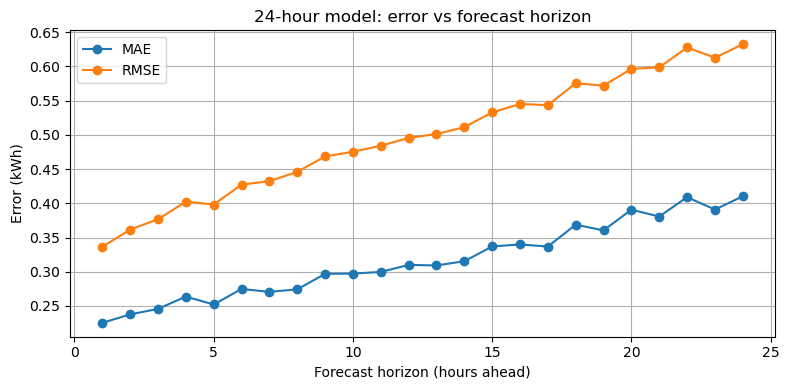

In [12]:
# Per-horizon metrics for 24-hour model
n_horizons = y_eval_24.shape[1]
mae_horizons = []
rmse_horizons = []

for h in range(n_horizons):
    y_true_h = y_eval_24[:, h]
    y_pred_h = y_pred_eval_24h[:, h]
    mse_h = mean_squared_error(y_true_h, y_pred_h)
    mae_h = mean_absolute_error(y_true_h, y_pred_h)
    rmse_h = mse_h ** 0.5

    mae_horizons.append(mae_h)
    rmse_horizons.append(rmse_h)

# Print a few
for h in [0, 5, 11, 23]:  # 1h, 6h, 12h, 24h ahead (0-based)
    print(f"Horizon {h+1:2d}h -> MAE: {mae_horizons[h]:.4f}, RMSE: {rmse_horizons[h]:.4f}")

# Plot
hours_ahead = np.arange(1, n_horizons + 1)

plt.figure(figsize=(8, 4))
plt.plot(hours_ahead, mae_horizons, marker="o", label="MAE")
plt.plot(hours_ahead, rmse_horizons, marker="o", label="RMSE")
plt.xlabel("Forecast horizon (hours ahead)")
plt.ylabel("Error (kWh)")
plt.title("24-hour model: error vs forecast horizon")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
